# Classification Images - MNIST

In [1]:
import warnings
warnings.filterwarnings('ignore')

from Training import Training
from Visualization import *
from Noise.GaborNoise.Gabor import Gabor
from Noise.Denoise.Denoise import Denoise
from CNN import MNIST_Model

import torch
import torch.utils.data.dataloader as dataloader
from torchvision import transforms
from torchvision.datasets import MNIST
import numpy as np
import cv2
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
import sys
import math
from SpikeTriggeredAveraging import SpikeTriggeredAveraging

from skimage.filters import gaussian
from skimage import exposure
from skimage.restoration import denoise_nl_means, estimate_sigma, denoise_tv_chambolle,denoise_bilateral,denoise_wavelet
import bm3d
from sklearn.decomposition import PCA

### MNIST Dataset

In [3]:
# Downloading Datasets
train = MNIST('./data', train=True, download=True, transform=transforms.Compose([
    transforms.ToTensor(),]),);

test = MNIST('./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),]),);

num_classes = len(train.classes)
img_shape = train.data[0].shape

In [4]:
# Creating Dataloaders
cuda = torch.cuda.is_available()

dataloader_args = dict(shuffle=True, batch_size=256,num_workers=4, pin_memory=True) if cuda else dict(shuffle=True, batch_size=64)
train_loader = dataloader.DataLoader(train, **dataloader_args)
test_loader = dataloader.DataLoader(test, **dataloader_args)

mnist_loader = {'train':train_loader,'test':test_loader}

### Visualizing our dataset

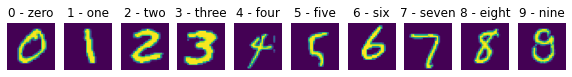

In [5]:
list_of_titles = train.classes
num_classes = len(list_of_titles)
display_data(data=train.data.numpy(),
                   targets = train.targets.numpy(),
                   class_names = list_of_titles,number_of_columns=num_classes)

### Generating Gabor Noise

$g(x,y;\lambda,\theta,\psi,\sigma,\gamma) = exp(\frac{x'^2+\gamma^2 y'^2}{2\sigma^2}) + exp(i(2\pi\frac{x'}{\lambda}+\psi))$  
$x' = x \cos(\theta) + y\sin(\theta)$   
$y' = -x \sin(\theta) + y\cos(\theta)$  
$\lambda = \text{Wavelength of the sinusoidal factor}$  
$\theta = \text{Orientation of the normal to the parallel stripes}$  
$\psi = \text{Phase offset}$  
$\sigma = \text{Standard deviation of the gaussian envelope}$  
$\gamma = \text{Spatial aspect ratio}$  

In [5]:
gabor = Gabor(pixel = img_shape[0])
n_theta = 4
n_psi = 2
Theta = [i * np.pi /n_theta for i in range(n_theta)]
Psi = [i * np.pi /n_psi for i in range(n_psi)]
ksize = [3, 7, 15]

In [6]:
gabor.generate_gabor_kernels(ksize,sigma_factor=7.0,
                             n_theta=Theta,lambd_factor=2.0,
                             gamma=0.5,n_psi=Psi,
                             ktype=cv2.CV_32F)

960 Gabor kernels have been generated


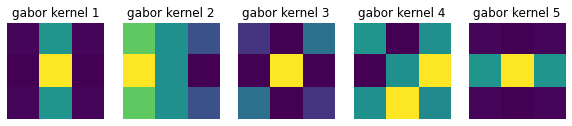

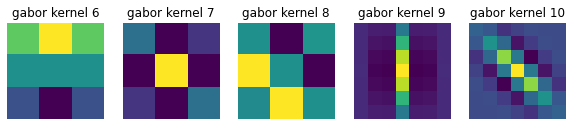

In [7]:
gabor_kernels = gabor.kernels['gabor']
gabor_img_display = [gabor_kernels[i]for i in range(0,960,100)]
gabor_img_title = ['gabor kernel '+str(i) for i in range(1,11)]
grid_display(gabor_img_display,gabor_img_title,5)

100%|██████████| 3/3 [00:00<00:00, 340.45it/s]
960 image kernels generated


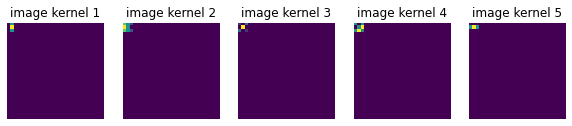

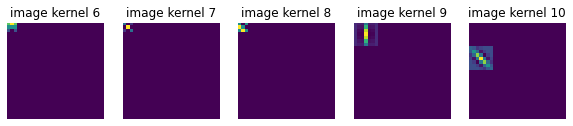

In [12]:
gabor.generate_image_kernels()
image_kernels = gabor.kernels['image']
image_kernel_display = [image_kernels[i]for i in range(0,960,100)]
img_title = ['image kernel '+str(i) for i in range(1,11)]
grid_display(image_kernel_display,img_title,5)

In an attempt to generate the gabor noise, we use Ridge Regression with a regularization factor of $\alpha=0.1$ to find the weights.  
The weights undergo Dimensionality Reduction with Principal Component Analysis. We keep the first 250 features and this amounts to 90% of the explained variance.  
The principal components and weights are later used to generate the noise samples.

In [11]:
'''n_noise = 1000000
reg_alpha = 0.1
pca_dim = 250
save_as = 'gabor_noise_mnist'
gabor.generate_noise(train_data=train.train_data,reg_alpha=reg_alpha,
                     pca_dim=pca_dim,n_noise=n_noise,save_as=save_as,save_bool=True)
reg_weights = gabor.reg_weights

mnist_reg_weights = np.save('cache/reg_weights_mnist.npy',reg_weights)'''

"n_noise = 1000000\nreg_alpha = 0.1\npca_dim = 250\nsave_as = 'gabor_noise_mnist'\ngabor.generate_noise(train_data=train.train_data,reg_alpha=reg_alpha,\n                     pca_dim=pca_dim,n_noise=n_noise,save_as=save_as,save_bool=True)\nreg_weights = gabor.reg_weights\n\nmnist_reg_weights = np.save('cache/reg_weights_mnist.npy',reg_weights)"

In [9]:
mnist_noise = np.load('cache/gabor_noise_mnist.npy')
reg_weights = np.load('cache/reg_weights_mnist.npy')

The generated image kernels and regression weights are used to reconstruct images

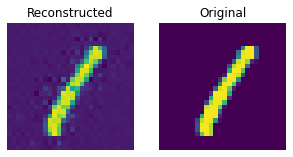

In [13]:
orig_v_reconstructed(img_kernels,reg_weights,train,3)

Here are 10 samples of the generated noise samples

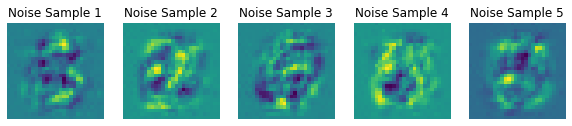

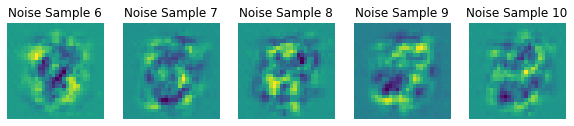

In [15]:
noise_maps(mnist_noise,10)

### Pass noise through model

We pass the MNIST DataLoader in our Neural Network. The neural network has 2 convolutional blocks and 2 fully connected layers.

In [15]:
model_MNIST = MNIST_Model()
model_MNIST.to(model_MNIST.device)
loss_func = nn.CrossEntropyLoss().to(model_MNIST.device)   
optimizer = optim.Adam(model_MNIST.parameters(), lr=1e-3)

In [18]:
model_MNIST.train_model(mnist_loader,epochs=20,loss_function=loss_func,optimizer=optimizer)

Epoch: 1 Train Loss: 1.48829 Train Accuracy: 0.96005                    Test Loss: 1.50251 Test Accuracy: 0.96160

Epoch: 2 Train Loss: 1.48168 Train Accuracy: 0.97590                    Test Loss: 1.48398 Test Accuracy: 0.97840

Epoch: 3 Train Loss: 1.49389 Train Accuracy: 0.98092                    Test Loss: 1.47933 Test Accuracy: 0.98180

Epoch: 4 Train Loss: 1.49522 Train Accuracy: 0.98387                    Test Loss: 1.47620 Test Accuracy: 0.98560

Epoch: 5 Train Loss: 1.47674 Train Accuracy: 0.98505                    Test Loss: 1.47665 Test Accuracy: 0.98510

Epoch: 6 Train Loss: 1.47826 Train Accuracy: 0.98592                    Test Loss: 1.47875 Test Accuracy: 0.98510

Epoch: 7 Train Loss: 1.49136 Train Accuracy: 0.98682                    Test Loss: 1.47540 Test Accuracy: 0.98680

Epoch: 8 Train Loss: 1.47767 Train Accuracy: 0.98965                    Test Loss: 1.47350 Test Accuracy: 0.98780

Epoch: 9 Train Loss: 1.46384 Train Accuracy: 0.99158                    Test Los

In [23]:
model_path = 'cache/mnist_e20_acc99070.pth'
torch.save(model_MNIST,model_path)

In [19]:
model = torch.load('cache/mnist_e20_acc99070.pth')
model = model.to('cuda')

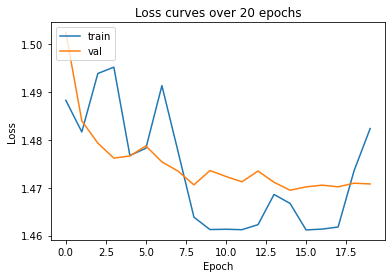

In [20]:
train_history = model.train_metrics
train_loss = train_history['train_loss']
val_loss = train_history['val_loss']
loss_curve(train_loss,val_loss,title="Loss curves over 20 epochs")

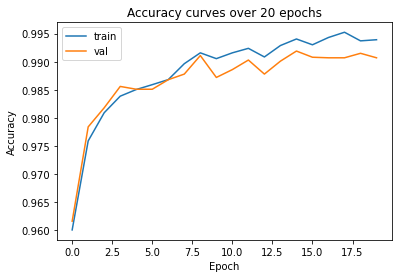

In [21]:
train_accuracy = train_history['train_accuracy']
val_accuracy = train_history['val_accuracy']
accuracy_curve(train_accuracy,val_accuracy,title="Accuracy curves over 20 epochs")

### Results - Model

In [22]:
test_data = test.data # 10K test images
test_data =test_data[:,None,...]
test_data= test_data.type(torch.FloatTensor).to(model.device)
test_data= (test_data - test_data.min())/(test_data.max() - test_data.min())

In [23]:
prediction = model(test_data)[0].max(1)[1]
ground_truth = test_loader.dataset.targets

In [24]:
prediction_cpu = prediction.cpu().numpy()
ground_truth_cpu = ground_truth.cpu().numpy()

<AxesSubplot:title={'center':'Confusion Matrix - Fashion MNIST'}, xlabel='True label', ylabel='Predicted label'>

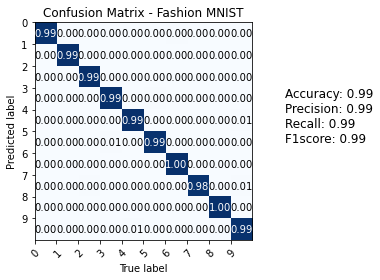

In [25]:
confusion_matrix(prediction_cpu,ground_truth_cpu,range(10),normalize=True,title = "Confusion Matrix - Fashion MNIST")

In [26]:
model.metrics_report(prediction_cpu,ground_truth_cpu)

,0,1,2,3,4,5,6,7,8,9
accuracy,0.987891,0.993822,0.992248,0.990089,0.992850,0.987668,0.995803,0.982709,0.995838,0.985134
f1-score,0.993404,0.992945,0.992248,0.989599,0.991331,0.987668,0.993197,0.988884,0.989147,0.985134
precision,0.998980,0.992070,0.992248,0.989109,0.989817,0.987668,0.990605,0.995136,0.982546,0.985134
recall,0.987891,0.993822,0.992248,0.990089,0.992850,0.987668,0.995803,0.982709,0.995838,0.985134
support,991.000000,1133.000000,1032.000000,1009.000000,979.000000,892.000000,953.000000,1041.000000,961.000000,1009.000000


In [27]:
model.classification_metrics(prediction_cpu,ground_truth_cpu)

{'accuracy': 0.9904,
 'f1score': 0.9903557558063097,
 'precision': 0.9903313523185673,
 'recall': 0.9904051125775142,
 'support': None}

### Results - Noise Activation

In [19]:
mnist_noise_data = gabor.noise_frequency(model=model,noise=mnist_noise,batch_size=10000,n_classes=10)

  1%|          | 1/100 [00:05<09:05,  5.51s/it]
0 : 82227
1 : 182
2 : 128334
3 : 125834
4 : 51706
5 : 98514
6 : 32614
7 : 38162
8 : 358260
9 : 84167


In [20]:
mean_noise = [(mnist_noise_data[i].mean(axis=0)) for i in range(10)]
mean_noise = torch.stack(mean_noise).to('cuda')

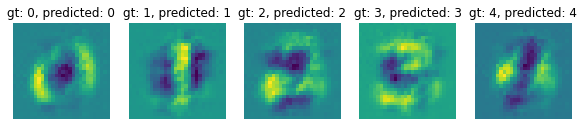

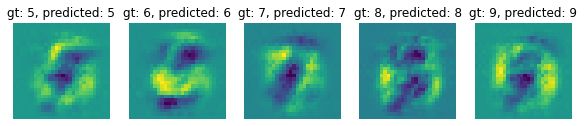

In [22]:
pred_values = model(mean_noise[:,None,...])[0].data.max(1)[1]
pred_gt_tuple = zip((range(10)),pred_values)
list_of_names = ["gt: {}, predicted: {}".format(i[0],i[1]) for i in pred_gt_tuple]
list_of_images = [i.cpu() for i in mean_noise]
grid_display(list_of_images,list_of_names,5)

In [ ]:
#np.save('cache/mnist_noise_average.npy',np.array(mean_noise.cpu()))

In [29]:
mean_noise = np.load('cache/mnist_noise_average.npy')

We now apply random noise patterns of each class to an image to see how the predictions vary as noise is applied

torch.Size([1, 1, 28, 28])
class: 0, misclassification_rate: 0.0
class: 1, misclassification_rate: 1.0
class: 2, misclassification_rate: 1.0
class: 3, misclassification_rate: 1.0
class: 4, misclassification_rate: 0.0
class: 5, misclassification_rate: 1.0
class: 6, misclassification_rate: 0.0
class: 7, misclassification_rate: 0.0
class: 8, misclassification_rate: 0.0
class: 9, misclassification_rate: 1.0


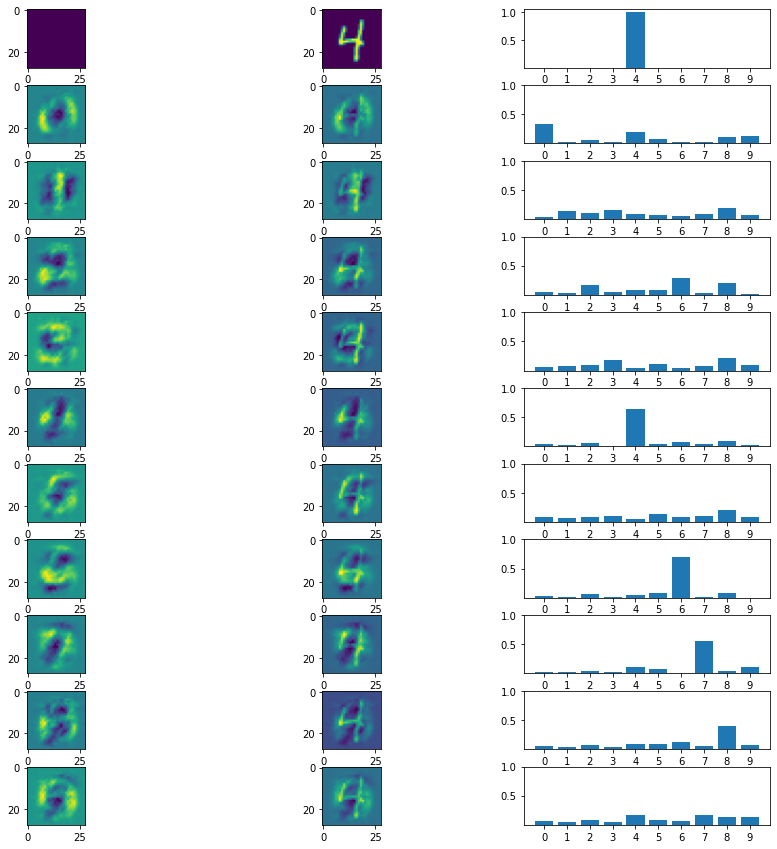

In [30]:
denoise = Denoise(model)
prediction_array,list_of_hist_im = denoise.noise_injection(torch.tensor(mean_noise), weights=0.9, test_data=test.data, image_idx=19)
grid_histogram(data = prediction_array, rows=11, columns=3, list_of_images=list_of_hist_im)

Let's now see how our model performs when noise is injected in the whole dataset

In [35]:
test_data = test.data.type(torch.FloatTensor)

In [36]:
prediction_noise_injected = model.prediction_transform(mean_noise,test_data)
ground_truth_noise_injected = test_loader.dataset.targets

prediction_noise_injected_cpu = prediction_noise_injected.cpu().numpy()
ground_truth_noise_injected_cpu = ground_truth_noise_injected.cpu().numpy()

<AxesSubplot:title={'center':'Confusion Matrix - Gabor Noisy MNIST'}, xlabel='True label', ylabel='Predicted label'>

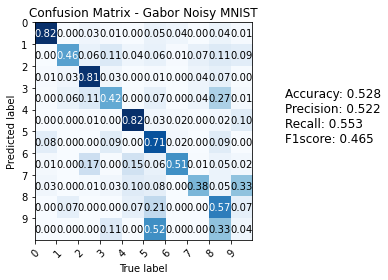

In [37]:
confusion_matrix(prediction_noise_injected_cpu,ground_truth_noise_injected_cpu,range(10),normalize=True,title = "Confusion Matrix - Gabor Noisy MNIST")

We notice a sharp decrease in class-wise accuracy as we start seeing more variance throughout the confusion matrix.

We perform the same analysis as above, however this time we will use random noise instead of gabor noise

In [38]:
prediction_frequency,mean_noise_rand = denoise.make_mean_activation_layer(size=1000000,batch_size=10000,n_classes=10,input_size=28)
mean_noise_rand = (mean_noise_rand -mean_noise_rand.min()) / (mean_noise_rand.max() -mean_noise_rand.min())

In [39]:
prediction_frequency

{0: tensor(1472, device='cuda:0'),
 1: tensor(1, device='cuda:0'),
 2: tensor(86461, device='cuda:0'),
 3: tensor(54539, device='cuda:0'),
 4: tensor(1445, device='cuda:0'),
 5: tensor(21561, device='cuda:0'),
 6: tensor(1459, device='cuda:0'),
 7: tensor(2206, device='cuda:0'),
 8: tensor(824995, device='cuda:0'),
 9: tensor(5861, device='cuda:0')}

In [40]:
mean_noise_rand = mean_noise_rand.to('cuda')
pred_values = model(mean_noise_rand[:,None,...])[0].data.max(1)[1]

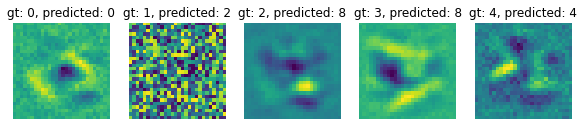

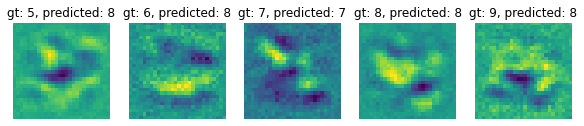

In [41]:
pred_gt_tuple = zip((range(10)),pred_values)
list_of_names = ["gt: {}, predicted: {}".format(i[0],i[1]) for i in pred_gt_tuple]
list_of_images = [i.cpu() for i in mean_noise_rand]
grid_display(list_of_images,list_of_names,5)

We immediately notice that the mean activation layers do not resemble the classes they are supposed to represent

In [43]:
mean_noise_rand = mean_noise_rand.cpu()

torch.Size([1, 1, 28, 28])
class: 0, misclassification_rate: 1.0
class: 1, misclassification_rate: 1.0
class: 2, misclassification_rate: 1.0
class: 3, misclassification_rate: 1.0
class: 4, misclassification_rate: 0.0
class: 5, misclassification_rate: 1.0
class: 6, misclassification_rate: 0.0
class: 7, misclassification_rate: 1.0
class: 8, misclassification_rate: 1.0
class: 9, misclassification_rate: 1.0


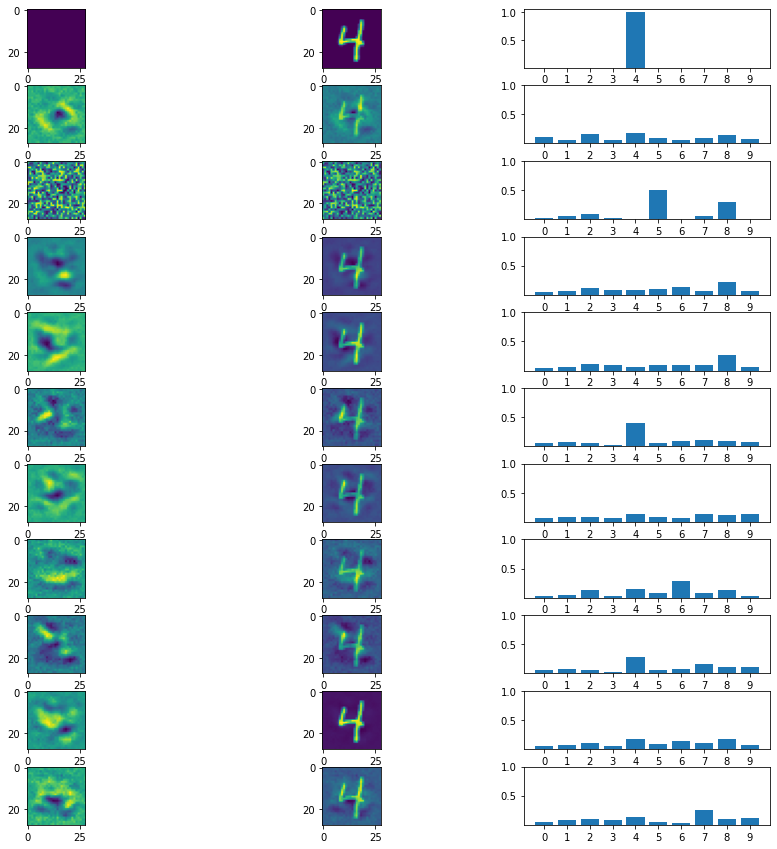

In [44]:
prediction_array_rand,list_of_hist_rand = denoise.noise_injection(torch.tensor(mean_noise_rand), weights=0.9, test_data=test.data, image_idx=19)
grid_histogram(data = prediction_array_rand, rows=11, columns=3, list_of_images=list_of_hist_rand)

### Spike Triggered Analysis

By defining the component sizes that make up a convolutional block, we can mathematically calculate the size of the input after being subsampled.  
We define the convnet array to represent a layer's properties in the order [kernel size, stride, padding, number_channel]

In [48]:
STA = SpikeTriggeredAveraging(model,28)
convnet =   [[5,1,0,32], [2,2,0,0], [5,1,0,64], [2,2,0,0]]
layer_names = ['conv1','pool1','conv2','pool2']

In [49]:
STA.generate_rf_info(layer_names=layer_names,layer_list=convnet)

[2.5, 1, 5, 24, 32]
[3.0, 2, 6, 12, 0]
[7.0, 2, 14, 8, 64]


{'conv1': [2.5, 1, 5, 24, 32],
 'pool1': [3.0, 2, 6, 12, 0],
 'conv2': [7.0, 2, 14, 8, 64],
 'pool2': [8.0, 4, 16, 4, 0]}

We pass the training data through the CNN again but this time we record the responses of the convolutional layers after activation.

In [50]:
convolutional_layers = STA.get_features_from_cnn(train_data=train.data,conv_layers=2, batch_size=10000,pos_x=3,pos_y=3)

100%|██████████| 6/6 [00:00<00:00, 20.46it/s]


In [51]:
img_num = len(train.data)
train_data = train.data

# Record layer activation
conv_activation_1 = convolutional_layers['conv1_activation']
conv_activation_2 = convolutional_layers['conv2_activation']

conv1_rf = torch.zeros(conv_activation_1.shape[1], 5, 5)
conv2_rf = torch.zeros(conv_activation_2.shape[1], 14, 14)

# Pad the image if needed to capture the layer activation
with tqdm(total=img_num, file=sys.stdout) as pbar:
    for i in range(img_num):
        image = train_data[i].type_as(torch.FloatTensor())
        conv1_rf += STA.padded_rf(layer_name = 'conv1',image = image, i=5,j=5)[None, ...].repeat(conv_activation_1.shape[1], 1, 1) * conv_activation_1[i][..., None, None]
        conv2_rf += STA.padded_rf(layer_name = 'conv2',image = image, i=5,j=5)[None, ...].repeat(conv_activation_2.shape[1], 1, 1) * conv_activation_2[i][..., None, None]

        pbar.update(1)

100%|██████████| 60000/60000 [00:08<00:00, 7236.20it/s]


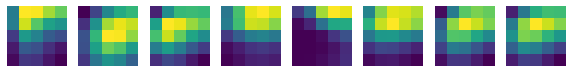

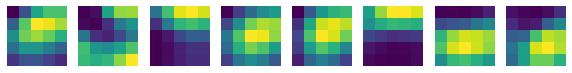

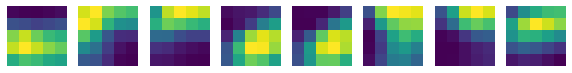

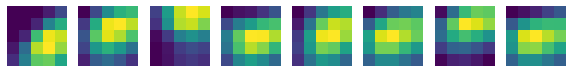

In [52]:
list_images_conv1 = [conv1_rf[i].numpy() for i in range(conv1_rf.shape[0])]
list_names_conv1 = [""] * conv1_rf.shape[0]
grid_display(list_images_conv1,list_names_conv1,8)

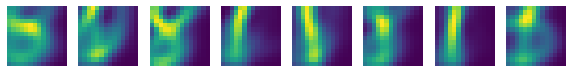

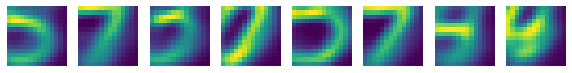

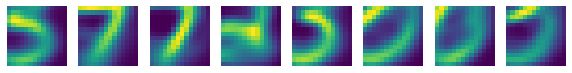

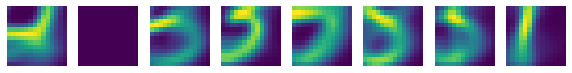

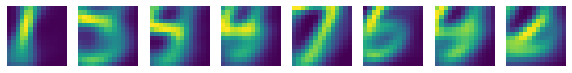

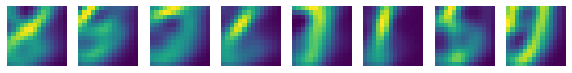

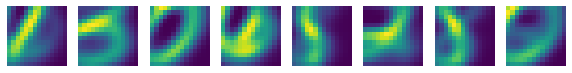

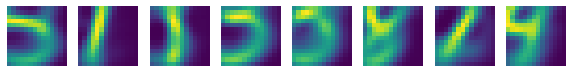

In [53]:
list_images_conv2 = [conv2_rf[i].numpy() for i in range(conv2_rf.shape[0])]
list_names_conv2 = [""] * conv2_rf.shape[0]
grid_display(list_images_conv2,list_names_conv2,8)

### Denoising

In [56]:
test_data = test.data # 10K test images
test_data =test_data[:,None,...]
test_data= test_data.type(torch.FloatTensor)
test_data= (test_data - test_data.min())/(test_data.max() - test_data.min())

We now pick a noise pattern, in this case the 3rd pattern, and inject said pattern in the clean original dataset.  

In [59]:
weight_injection = 0.85
noise_pattern = mean_noise[3]
injected_test = weight_injection*noise_pattern + (1-weight_injection)*(test_data.cpu().numpy())
injected_test = torch.tensor(injected_test).cuda()

In [60]:
with torch.no_grad():
    injected_prediction = model(injected_test)[0].max(1)[1]

<AxesSubplot:title={'center':'Confusion Matrix - Gabor 3-Noisy MNIST'}, xlabel='True label', ylabel='Predicted label'>

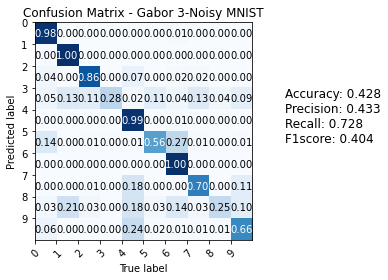

In [61]:
injected_prediction = injected_prediction.cpu().numpy()
ground_truth_test = test.targets.numpy()
confusion_matrix(injected_prediction,ground_truth_test,range(10),normalize=True,
                            title = "Confusion Matrix - Gabor 3-Noisy MNIST")

We predict the results and notice that model accuracy dropped by around 50%.
We notice that the row representing the 3rd class has predictions throughout all classes instead of being concentrated around the 3rd class diagonal.

### Not-Gabor Noise

In [62]:
rand_dict, mean_noise_basic = denoise.make_mean_activation_layer(size = 1000000,batch_size=10000,n_classes=10,input_size=28)

In [64]:
rand_dict

{0: tensor(1521, device='cuda:0'),
 1: tensor(1, device='cuda:0'),
 2: tensor(85865, device='cuda:0'),
 3: tensor(54432, device='cuda:0'),
 4: tensor(1463, device='cuda:0'),
 5: tensor(21549, device='cuda:0'),
 6: tensor(1519, device='cuda:0'),
 7: tensor(2160, device='cuda:0'),
 8: tensor(825683, device='cuda:0'),
 9: tensor(5807, device='cuda:0')}

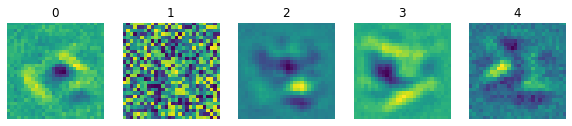

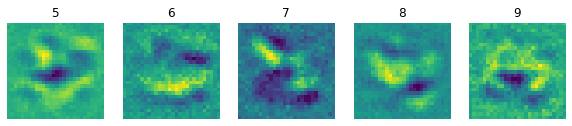

In [65]:
grid_display(mean_noise_basic,list(range(10)),no_of_columns=5)

List of denoising methods
- PCA
- Total Variation
- Bilateral
- Wavelet denoising
- Gaussian Blur
- NL Means
- BM 3D

In [75]:
def PCA_transform(image,percentage):
    pca = PCA(n_components=percentage)
    pca_fit = pca.fit(image)
    pca_transformed = pca_fit.transform(image)
    projection = pca_fit.inverse_transform(pca_transformed)
    return projection

In [76]:
pca_lambda = (lambda x: PCA_transform(x,0.95))
tv_lambda = (lambda x: denoise_tv_chambolle(x,weight=0.0125,eps=0.0001,n_iter_max=200))
bilateral_lambda = (lambda x: denoise_bilateral(x,channel_axis=None,sigma_spatial=0.01))
wavelet_visushrink_lambda = (lambda x: denoise_wavelet(x, channel_axis=None, convert2ycbcr=False,
                           method='VisuShrink', mode='hard',sigma=1e-6,
                           rescale_sigma=True))
wavelet_bayes_lambda = (lambda x: denoise_wavelet(x, channel_axis=None, convert2ycbcr=False,
                           method='BayesShrink', mode='soft',
                           rescale_sigma=True))
gauss_lambda =(lambda x: gaussian(x,sigma=0.015,mode='constant',cval=0.0))
nl_means_lambda = (lambda x: denoise_nl_means(x, h=1.15*estimate_sigma(x,multichannel=False),
                                              fast_mode = True, patch_size = 3,
                                              patch_distance = 1, multichannel = False))
bm3d_lambda = (lambda x: bm3d.bm3d(x, sigma_psd=0.01, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING))

We apply a collection of denoising methods to our base image to see how denoising would help our cause.

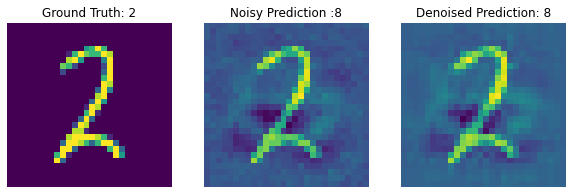

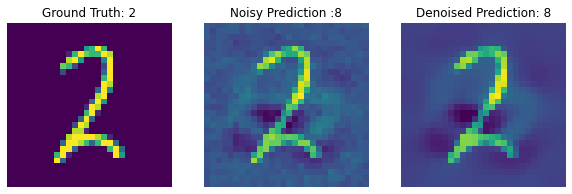

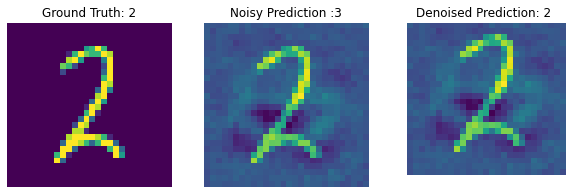

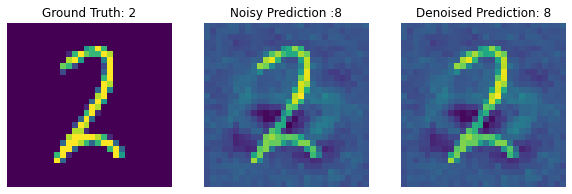

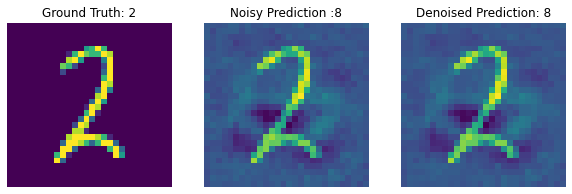

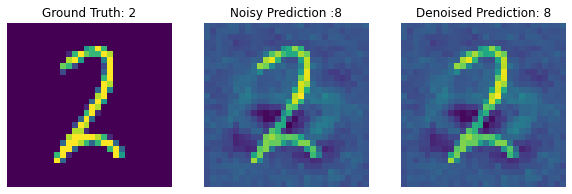

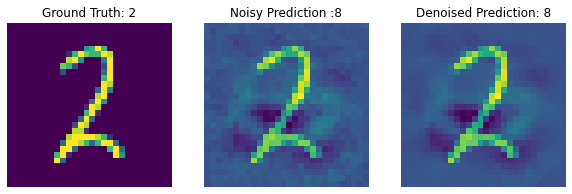

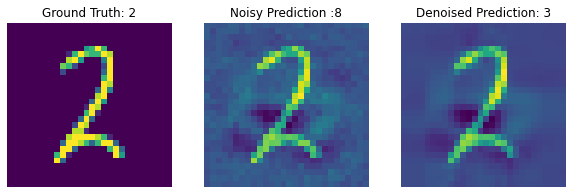

In [77]:
denoisers = [pca_lambda,tv_lambda,bilateral_lambda,wavelet_visushrink_lambda,wavelet_bayes_lambda,gauss_lambda,nl_means_lambda,bm3d_lambda]
for denoiser_ld in denoisers:
    l_img_pca,l_n_pca = denoise.denoising_image_prediction(mean_noise_basic[9], test_data[1412],
                                                   test.targets[1412] ,denoiser_ld, weight_injection=0.9)
    grid_display(l_img_pca,l_n_pca,no_of_columns=3)
    

### Image segmentation

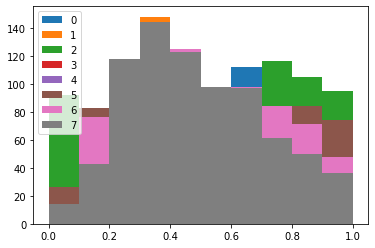

In [87]:
for denoiser in denoisers:
    test_image_mk = test_data[1412]
    weight_injection = 0.9
    noise_pattern = mean_noise_basic[9]
    injected_noise_k = weight_injection*noise_pattern + (1-weight_injection)*(test_image_mk.cpu().numpy())
    
    denoised_img_nl = denoiser(injected_noise_k.reshape(28,28).numpy())
    equalizer_img = exposure.equalize_adapthist(denoised_img_nl)
    plt.hist(equalizer_img.flat,bins=10,range=(0,1))
    handles = list(range(8))
    plt.legend(handles)

By plotting a histogram of the pixel values distribution, we notice that the right tail under bm3d denoising is light.  
This implies that a small amount of the pixel values are greater than the 90th percentile.  
These pixel values could eliminate the noise we are dealing with

(array([ 14.,  43., 118., 144., 123.,  98.,  97.,  61.,  50.,  36.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

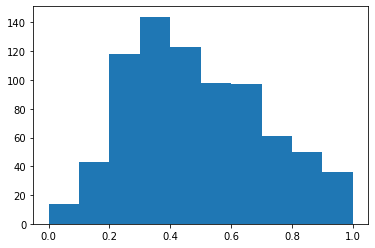

In [88]:
test_image_mk = test_data[1412]
weight_injection = 0.9
noise_pattern = mean_noise_basic[9]
injected_noise_k = weight_injection*noise_pattern + (1-weight_injection)*(test_image_mk.cpu().numpy())

denoised_img_nl = bm3d_lambda(injected_noise_k.reshape(28,28).numpy())
equalizer_img = exposure.equalize_adapthist(denoised_img_nl)
plt.hist(equalizer_img.flat,bins=10,range=(0,1))

In [89]:
markers = np.zeros((28,28))
threshold = np.percentile(equalizer_img,90)
markers[(equalizer_img < threshold)] = 0
markers[(equalizer_img > threshold)] = 1

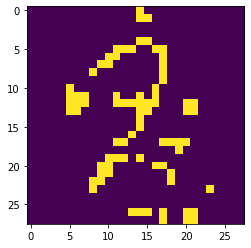

In [90]:
plt.imshow(markers)

By applying this marker mask, we highlight the dominant pixels that make up our original image.  
We can now see the 2 rather clearly.

In [81]:
train_data_mask = denoise.denoise_mask_transform(data = test.data,
                                         pixel = 28,
                                         noise_pattern = mean_noise_basic[9],
                                         noise_weight = 0.8,
                                         denoiser_lambda = bm3d_lambda,
                                         percentile_threshold = np.percentile(equalizer_img.flat,90))

In [82]:
with torch.no_grad():
    markers_dataset = torch.tensor(train_data_mask[:,None,...]).type(torch.FloatTensor).cuda()
    marked_pred = model(markers_dataset)[0].max(1)[1]
marked_pred

tensor([7, 2, 1,  ..., 4, 5, 6], device='cuda:0')

<AxesSubplot:title={'center':'Confusion Matrix - Marker MNIST'}, xlabel='True label', ylabel='Predicted label'>

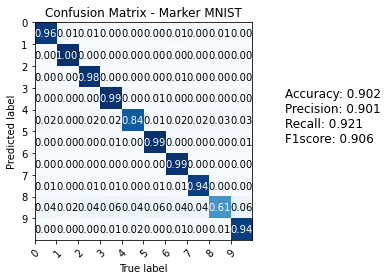

In [83]:
marked_pred = marked_pred.cpu().numpy()
ground_truth_test = test.targets.numpy()
confusion_matrix(marked_pred,ground_truth_test,range(10),normalize=True,
                            title = "Confusion Matrix - Marker MNIST")

This denoising technique helped us increase our accuracy from